In [3]:

print("Detroit Tigers Analytics Project")

Detroit Tigers Analytics Project


# Detroit Tigers Hitter Analysis

This notebook evaluates Detroit Tigers hitters using Statcast expected metrics, quality-of-contact indicators, and plate-discipline measures.

## Research Question

Which Detroit Tigers hitters show the strongest underlying offensive profiles, and whose actual results differ most from expected performance?

## 1. Data Preparation

The analysis uses 2026 Detroit Tigers hitting data. Hitters with fewer than 100 plate appearances are excluded from the primary analysis to reduce the impact of very small samples.

## 2. Derived Metrics

The following metrics are calculated:

- xwOBA Gap = xwOBA - wOBA
- xSLG Gap = xSLG - SLG
- AVG Gap = xBA - AVG
- BB/K Ratio = BB% / K%

Positive expected-performance gaps indicate that expected results were stronger than actual results.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
df = pd.read_csv("tigers_2026_hitting.csv")

In [8]:
df.head()

,Player Name,PA,xwOBA Gap,xSLG Gap,AVG Gap,BB/K Ratio,Performance Category,wOBA,xwOBA,Hard-Hit %,...,Unnamed: 72,Unnamed: 73,Unnamed: 74,Unnamed: 75,Unnamed: 76,Unnamed: 77,Unnamed: 78,Unnamed: 79,Unnamed: 80,Unnamed: 81
0,Riley Greene,592.0,0.003,0.023,-0.018,0.45,Results Match Expectations,0.366,0.369,46.00%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Eduardo Valencia,138.0,-0.061,-0.090,-0.056,0.19,Outperforming Expected Results,0.433,0.372,49.50%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Dillon Dingler,607.0,0.019,0.022,0.023,0.24,Results Match Expectations,0.325,0.344,43.40%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Kevin McGonigle,707.0,-0.002,0.015,-0.014,0.95,Results Match Expectations,0.357,0.355,37.60%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Colt Keith,423.0,0.012,0.017,0.014,0.38,Results Match Expectations,0.321,0.333,42.10%,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

In [13]:
df.shape

(68, 17)

In [14]:
df.columns.tolist()

['Player Name',
 'PA',
 'xwOBA Gap',
 'xSLG Gap',
 'AVG Gap',
 'BB/K Ratio',
 'Performance Category',
 'wOBA',
 'xwOBA',
 'Hard-Hit %',
 'Barrel %',
 'xwOBA Percentile',
 'Hard-Hit Percentile',
 'Barrel Percentile',
 'Discipline Percentile',
 'Sustainability Score',
 'Rank']

In [15]:
df.head()

,Player Name,PA,xwOBA Gap,xSLG Gap,AVG Gap,BB/K Ratio,Performance Category,wOBA,xwOBA,Hard-Hit %,Barrel %,xwOBA Percentile,Hard-Hit Percentile,Barrel Percentile,Discipline Percentile,Sustainability Score,Rank
0,Riley Greene,592.0,0.003,0.023,-0.018,0.45,Results Match Expectations,0.366,0.369,46.00%,14.80%,93%,93%,93%,64%,88.510,1.0
1,Eduardo Valencia,138.0,-0.061,-0.090,-0.056,0.19,Outperforming Expected Results,0.433,0.372,49.50%,15.50%,100%,100%,100%,7%,86.065,2.0
2,Dillon Dingler,607.0,0.019,0.022,0.023,0.24,Results Match Expectations,0.325,0.344,43.40%,10.10%,79%,79%,79%,14%,68.855,3.0
3,Kevin McGonigle,707.0,-0.002,0.015,-0.014,0.95,Results Match Expectations,0.357,0.355,37.60%,7.30%,86%,36%,43%,100%,66.765,4.0
4,Colt Keith,423.0,0.012,0.017,0.014,0.38,Results Match Expectations,0.321,0.333,42.10%,7.60%,71%,64%,50%,43%,61.030,5.0


In [16]:
raw_df = pd.read_csv("tigers_2026_raw.csv")
raw_df.head()

,Player Name,Age,PA,AVG,OBP,SLG,OPS,HR,BB%,K%,Exit Velocity,Hard-Hit %,Barrel %,wOBA,xwOBA,xBA,xSLG,xwOBA Gap,xSLG Gap,Sample Size
0,Ben Malgeri,26,140,0.250,0.350,0.417,0.767,5,12.10%,25.70%,90.1,42.40%,7.10%,0.341,0.317,0.243,0.354,-0.024,-0.063,Small Sample
1,Brett Callahan,24,80,0.211,0.287,0.324,0.611,1,8.80%,33.80%,89.9,44.40%,11.10%,0.274,0.296,0.211,0.375,0.022,0.051,Very Small Sample
2,Colt Keith,24,423,0.258,0.322,0.406,0.728,10,7.60%,19.90%,88.7,42.10%,7.60%,0.321,0.333,0.272,0.423,0.012,0.017,Medium Sample
3,Corey Julks,30,7,0.286,0.286,0.429,0.715,0,0.00%,14.30%,87.9,33.30%,0.00%,0.307,0.188,0.172,0.270,-0.119,-0.159,Very Small Sample
4,Dillon Dingler,27,607,0.243,0.302,0.446,0.748,27,5.60%,22.90%,88.8,43.40%,10.10%,0.325,0.344,0.266,0.468,0.019,0.022,Large Sample


In [17]:
raw_df.shape

(20, 20)

In [18]:
raw_df["Player Name"]

0           Ben Malgeri
1        Brett Callahan
2            Colt Keith
3           Corey Julks
4        Dillon Dingler
5      Eduardo Valencia
6        Gleyber Torres
7            Hao-Yu Lee
8             Jace Jung
9           Javier Báez
10            John Peck
11      Kerry Carpenter
12      Kevin McGonigle
13        Matt Vierling
14            Max Clark
15       Parker Meadows
16         Riley Greene
17    Spencer Torkelson
18        Wenceel Pérez
19       Zach McKinstry
Name: Player Name, dtype: object

In [19]:
raw_df

,Player Name,Age,PA,AVG,OBP,SLG,OPS,HR,BB%,K%,Exit Velocity,Hard-Hit %,Barrel %,wOBA,xwOBA,xBA,xSLG,xwOBA Gap,xSLG Gap,Sample Size
0,Ben Malgeri,26,140,0.250,0.350,0.417,0.767,5,12.10%,25.70%,90.1,42.40%,7.10%,0.341,0.317,0.243,0.354,-0.024,-0.063,Small Sample
1,Brett Callahan,24,80,0.211,0.287,0.324,0.611,1,8.80%,33.80%,89.9,44.40%,11.10%,0.274,0.296,0.211,0.375,0.022,0.051,Very Small Sample
2,Colt Keith,24,423,0.258,0.322,0.406,0.728,10,7.60%,19.90%,88.7,42.10%,7.60%,0.321,0.333,0.272,0.423,0.012,0.017,Medium Sample
3,Corey Julks,30,7,0.286,0.286,0.429,0.715,0,0.00%,14.30%,87.9,33.30%,0.00%,0.307,0.188,0.172,0.270,-0.119,-0.159,Very Small Sample
4,Dillon Dingler,27,607,0.243,0.302,0.446,0.748,27,5.60%,22.90%,88.8,43.40%,10.10%,0.325,0.344,0.266,0.468,0.019,0.022,Large Sample
5,Eduardo Valencia,26,138,0.341,0.380,0.636,1.016,8,4.30%,23.20%,90.3,49.50%,15.50%,0.433,0.372,0.285,0.546,-0.061,-0.090,Small Sample
6,Gleyber Torres,29,420,0.260,0.364,0.363,0.727,8,13.60%,19.30%,86.2,32.30%,6.10%,0.328,0.325,0.252,0.368,-0.003,0.005,Medium Sample
7,Hao-Yu Lee,23,364,0.264,0.322,0.424,0.746,10,8.20%,23.90%,89.5,41.30%,8.50%,0.325,0.302,0.234,0.393,-0.023,-0.031,Medium Sample
8,Jace Jung,26,11,0.222,0.364,0.222,0.586,0,18.20%,27.30%,84.2,16.70%,0.00%,0.289,0.367,0.301,0.376,0.078,0.154,Very Small Sample
9,Javier Báez,33,196,0.241,0.270,0.364,0.634,3,3.10%,20.90%,85.6,34.70%,2.70%,0.277,0.266,0.242,0.325,-0.011,-0.039,Small Sample


In [20]:
pd.set_option("display.max_rows", None)
raw_df

,Player Name,Age,PA,AVG,OBP,SLG,OPS,HR,BB%,K%,Exit Velocity,Hard-Hit %,Barrel %,wOBA,xwOBA,xBA,xSLG,xwOBA Gap,xSLG Gap,Sample Size
0,Ben Malgeri,26,140,0.250,0.350,0.417,0.767,5,12.10%,25.70%,90.1,42.40%,7.10%,0.341,0.317,0.243,0.354,-0.024,-0.063,Small Sample
1,Brett Callahan,24,80,0.211,0.287,0.324,0.611,1,8.80%,33.80%,89.9,44.40%,11.10%,0.274,0.296,0.211,0.375,0.022,0.051,Very Small Sample
2,Colt Keith,24,423,0.258,0.322,0.406,0.728,10,7.60%,19.90%,88.7,42.10%,7.60%,0.321,0.333,0.272,0.423,0.012,0.017,Medium Sample
3,Corey Julks,30,7,0.286,0.286,0.429,0.715,0,0.00%,14.30%,87.9,33.30%,0.00%,0.307,0.188,0.172,0.270,-0.119,-0.159,Very Small Sample
4,Dillon Dingler,27,607,0.243,0.302,0.446,0.748,27,5.60%,22.90%,88.8,43.40%,10.10%,0.325,0.344,0.266,0.468,0.019,0.022,Large Sample
5,Eduardo Valencia,26,138,0.341,0.380,0.636,1.016,8,4.30%,23.20%,90.3,49.50%,15.50%,0.433,0.372,0.285,0.546,-0.061,-0.090,Small Sample
6,Gleyber Torres,29,420,0.260,0.364,0.363,0.727,8,13.60%,19.30%,86.2,32.30%,6.10%,0.328,0.325,0.252,0.368,-0.003,0.005,Medium Sample
7,Hao-Yu Lee,23,364,0.264,0.322,0.424,0.746,10,8.20%,23.90%,89.5,41.30%,8.50%,0.325,0.302,0.234,0.393,-0.023,-0.031,Medium Sample
8,Jace Jung,26,11,0.222,0.364,0.222,0.586,0,18.20%,27.30%,84.2,16.70%,0.00%,0.289,0.367,0.301,0.376,0.078,0.154,Very Small Sample
9,Javier Báez,33,196,0.241,0.270,0.364,0.634,3,3.10%,20.90%,85.6,34.70%,2.70%,0.277,0.266,0.242,0.325,-0.011,-0.039,Small Sample


In [21]:
analysis_df = raw_df[raw_df["PA"] >= 100].copy()
analysis_df

,Player Name,Age,PA,AVG,OBP,SLG,OPS,HR,BB%,K%,Exit Velocity,Hard-Hit %,Barrel %,wOBA,xwOBA,xBA,xSLG,xwOBA Gap,xSLG Gap,Sample Size
0,Ben Malgeri,26,140,0.250,0.350,0.417,0.767,5,12.10%,25.70%,90.1,42.40%,7.10%,0.341,0.317,0.243,0.354,-0.024,-0.063,Small Sample
2,Colt Keith,24,423,0.258,0.322,0.406,0.728,10,7.60%,19.90%,88.7,42.10%,7.60%,0.321,0.333,0.272,0.423,0.012,0.017,Medium Sample
4,Dillon Dingler,27,607,0.243,0.302,0.446,0.748,27,5.60%,22.90%,88.8,43.40%,10.10%,0.325,0.344,0.266,0.468,0.019,0.022,Large Sample
5,Eduardo Valencia,26,138,0.341,0.380,0.636,1.016,8,4.30%,23.20%,90.3,49.50%,15.50%,0.433,0.372,0.285,0.546,-0.061,-0.090,Small Sample
6,Gleyber Torres,29,420,0.260,0.364,0.363,0.727,8,13.60%,19.30%,86.2,32.30%,6.10%,0.328,0.325,0.252,0.368,-0.003,0.005,Medium Sample
7,Hao-Yu Lee,23,364,0.264,0.322,0.424,0.746,10,8.20%,23.90%,89.5,41.30%,8.50%,0.325,0.302,0.234,0.393,-0.023,-0.031,Medium Sample
9,Javier Báez,33,196,0.241,0.270,0.364,0.634,3,3.10%,20.90%,85.6,34.70%,2.70%,0.277,0.266,0.242,0.325,-0.011,-0.039,Small Sample
11,Kerry Carpenter,28,259,0.208,0.276,0.416,0.692,13,6.90%,29.00%,89.8,44.00%,9.60%,0.301,0.295,0.212,0.388,-0.006,-0.028,Medium Sample
12,Kevin McGonigle,21,707,0.278,0.376,0.430,0.806,18,13.40%,14.10%,87.8,37.60%,7.30%,0.357,0.355,0.264,0.445,-0.002,0.015,Large Sample
13,Matt Vierling,29,291,0.207,0.255,0.335,0.590,5,6.50%,16.80%,87.9,37.20%,5.00%,0.258,0.304,0.256,0.381,0.046,0.046,Medium Sample


In [25]:
analysis_df = raw_df[raw_df["PA"] >= 100].copy()

In [26]:
percent_cols = ["BB%", "K%", "Hard-Hit %", "Barrel %"]

for col in percent_cols:
    analysis_df[col] = (
        analysis_df[col]
        .astype(str)
        .str.rstrip("%")
        .astype(float)
        / 100
    )

In [27]:
analysis_df[["Player Name", "BB%", "K%", "Hard-Hit %", "Barrel %"]].head()

,Player Name,BB%,K%,Hard-Hit %,Barrel %
0,Ben Malgeri,0.121,0.257,0.424,0.071
2,Colt Keith,0.076,0.199,0.421,0.076
4,Dillon Dingler,0.056,0.229,0.434,0.101
5,Eduardo Valencia,0.043,0.232,0.495,0.155
6,Gleyber Torres,0.136,0.193,0.323,0.061


In [28]:
analysis_df["xwOBA Gap"] = analysis_df["xwOBA"] - analysis_df["wOBA"]
analysis_df["xSLG Gap"] = analysis_df["xSLG"] - analysis_df["SLG"]
analysis_df["AVG Gap"] = analysis_df["xBA"] - analysis_df["AVG"]
analysis_df["BB/K Ratio"] = analysis_df["BB%"] / analysis_df["K%"]

In [29]:
def performance_category(gap):
    if gap >= 0.025:
        return "Underperforming Expected Results"
    elif gap <= -0.025:
        return "Outperforming Expected Results"
    else:
        return "Results Match Expectations"

analysis_df["Performance Category"] = analysis_df["xwOBA Gap"].apply(performance_category)

In [30]:
analysis_df[
    [
        "Player Name",
        "PA",
        "xwOBA Gap",
        "xSLG Gap",
        "AVG Gap",
        "BB/K Ratio",
        "Performance Category"
    ]
]

,Player Name,PA,xwOBA Gap,xSLG Gap,AVG Gap,BB/K Ratio,Performance Category
0,Ben Malgeri,140,-0.024,-0.063,-0.007,0.470817,Results Match Expectations
2,Colt Keith,423,0.012,0.017,0.014,0.381910,Results Match Expectations
4,Dillon Dingler,607,0.019,0.022,0.023,0.244541,Results Match Expectations
5,Eduardo Valencia,138,-0.061,-0.090,-0.056,0.185345,Outperforming Expected Results
6,Gleyber Torres,420,-0.003,0.005,-0.008,0.704663,Results Match Expectations
7,Hao-Yu Lee,364,-0.023,-0.031,-0.030,0.343096,Results Match Expectations
9,Javier Báez,196,-0.011,-0.039,0.001,0.148325,Results Match Expectations
11,Kerry Carpenter,259,-0.006,-0.028,0.004,0.237931,Results Match Expectations
12,Kevin McGonigle,707,-0.002,0.015,-0.014,0.950355,Results Match Expectations
13,Matt Vierling,291,0.046,0.046,0.049,0.386905,Underperforming Expected Results


In [31]:
analysis_df["xwOBA Percentile"] = analysis_df["xwOBA"].rank(pct=True)
analysis_df["Hard-Hit Percentile"] = analysis_df["Hard-Hit %"].rank(pct=True)
analysis_df["Barrel Percentile"] = analysis_df["Barrel %"].rank(pct=True)
analysis_df["Discipline Percentile"] = analysis_df["BB/K Ratio"].rank(pct=True)

In [32]:
analysis_df["Sustainability Score"] = 100 * (
    analysis_df["xwOBA Percentile"] * 0.40
    + analysis_df["Hard-Hit Percentile"] * 0.25
    + analysis_df["Barrel Percentile"] * 0.20
    + analysis_df["Discipline Percentile"] * 0.15
)

In [33]:
analysis_df["Rank"] = analysis_df["Sustainability Score"].rank(
    method="min",
    ascending=False
).astype(int)

In [34]:
analysis_df[
    ["Player Name", "Sustainability Score", "Rank"]
].sort_values("Rank")

,Player Name,Sustainability Score,Rank
16,Riley Greene,89.333333,1
5,Eduardo Valencia,87.000000,2
4,Dillon Dingler,72.000000,3
12,Kevin McGonigle,69.000000,4
2,Colt Keith,64.333333,5
0,Ben Malgeri,61.333333,6
17,Spencer Torkelson,58.333333,7
6,Gleyber Torres,50.666667,8
11,Kerry Carpenter,50.000000,9
7,Hao-Yu Lee,45.000000,10


## 4. Actual vs. Expected Performance

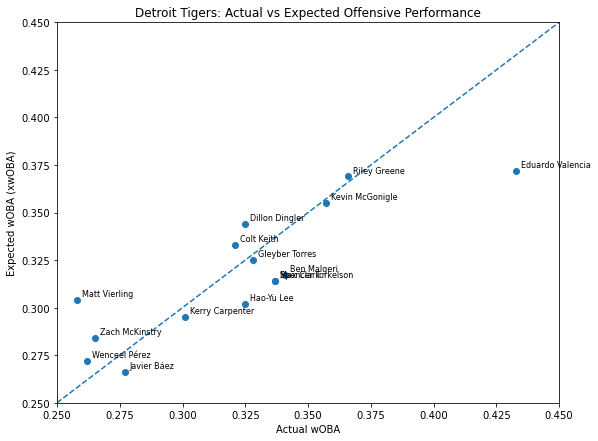

In [35]:
plt.figure(figsize=(9, 7))

plt.scatter(
    analysis_df["wOBA"],
    analysis_df["xwOBA"]
)

for _, row in analysis_df.iterrows():
    plt.text(
        row["wOBA"] + 0.002,
        row["xwOBA"] + 0.002,
        row["Player Name"],
        fontsize=8
    )

plt.plot(
    [0.25, 0.45],
    [0.25, 0.45],
    linestyle="--"
)

plt.xlabel("Actual wOBA")
plt.ylabel("Expected wOBA (xwOBA)")
plt.title("Detroit Tigers: Actual vs Expected Offensive Performance")

plt.xlim(0.25, 0.45)
plt.ylim(0.25, 0.45)

plt.show()

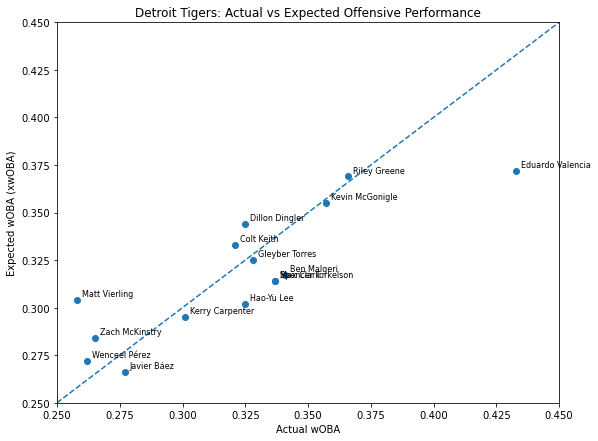

In [36]:
plt.figure(figsize=(9, 7))

plt.scatter(
    analysis_df["wOBA"],
    analysis_df["xwOBA"]
)

for _, row in analysis_df.iterrows():
    plt.text(
        row["wOBA"] + 0.002,
        row["xwOBA"] + 0.002,
        row["Player Name"],
        fontsize=8
    )

plt.plot(
    [0.25, 0.45],
    [0.25, 0.45],
    linestyle="--"
)

plt.xlabel("Actual wOBA")
plt.ylabel("Expected wOBA (xwOBA)")
plt.title("Detroit Tigers: Actual vs Expected Offensive Performance")

plt.xlim(0.25, 0.45)
plt.ylim(0.25, 0.45)

plt.show()

In [37]:
import matplotlib.pyplot as plt

In [38]:
plt.savefig("actual_vs_expected_python.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

In [39]:
plt.savefig("actual_vs_expected_python.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

In [40]:
plt.savefig("actual_vs_expected_python.png", dpi=300, bbox_inches="tight")

<Figure size 432x288 with 0 Axes>

## 5. Quality of Contact

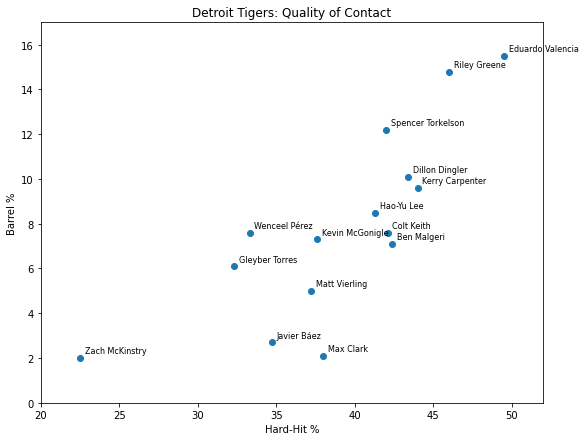

In [41]:
plt.figure(figsize=(9, 7))

plt.scatter(
    analysis_df["Hard-Hit %"] * 100,
    analysis_df["Barrel %"] * 100
)

for _, row in analysis_df.iterrows():
    plt.text(
        row["Hard-Hit %"] * 100 + 0.3,
        row["Barrel %"] * 100 + 0.2,
        row["Player Name"],
        fontsize=8
    )

plt.xlabel("Hard-Hit %")
plt.ylabel("Barrel %")
plt.title("Detroit Tigers: Quality of Contact")

plt.xlim(20, 52)
plt.ylim(0, 17)

plt.savefig("quality_of_contact_python.png", dpi=300, bbox_inches="tight")

plt.show()

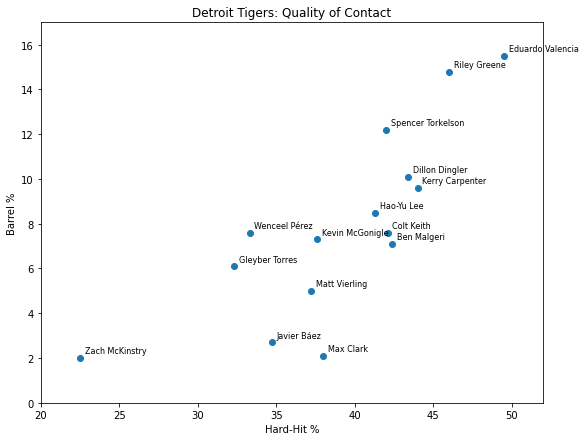

In [42]:
plt.figure(figsize=(9, 7))

plt.scatter(
    analysis_df["Hard-Hit %"] * 100,
    analysis_df["Barrel %"] * 100
)

for _, row in analysis_df.iterrows():
    plt.text(
        row["Hard-Hit %"] * 100 + 0.3,
        row["Barrel %"] * 100 + 0.2,
        row["Player Name"],
        fontsize=8
    )

plt.xlabel("Hard-Hit %")
plt.ylabel("Barrel %")
plt.title("Detroit Tigers: Quality of Contact")

plt.xlim(20, 52)
plt.ylim(0, 17)

plt.savefig("quality_of_contact_python.png", dpi=300, bbox_inches="tight")

plt.show()

## 6. Plate Discipline

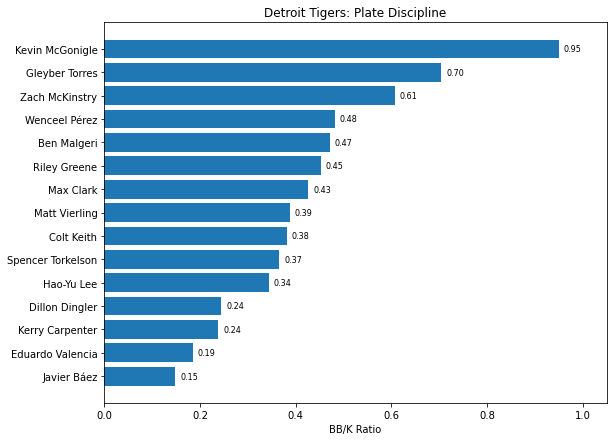

In [43]:
plate_df = analysis_df.sort_values("BB/K Ratio", ascending=True)

plt.figure(figsize=(9, 7))

plt.barh(
    plate_df["Player Name"],
    plate_df["BB/K Ratio"]
)

plt.xlabel("BB/K Ratio")
plt.title("Detroit Tigers: Plate Discipline")

for i, value in enumerate(plate_df["BB/K Ratio"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8
    )

plt.xlim(0, 1.05)

plt.savefig("plate_discipline_python.png", dpi=300, bbox_inches="tight")

plt.show()

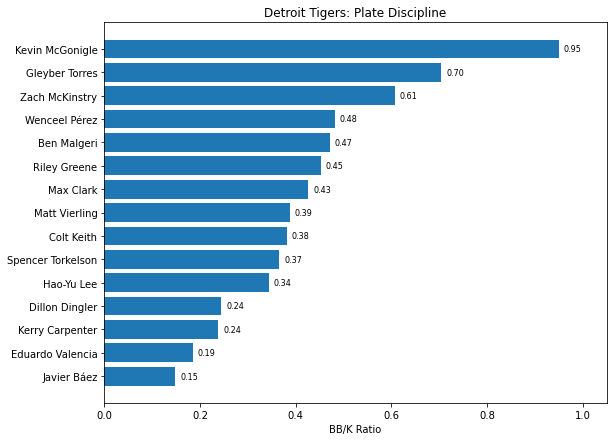

In [44]:
plate_df = analysis_df.sort_values("BB/K Ratio", ascending=True)

plt.figure(figsize=(9, 7))

plt.barh(
    plate_df["Player Name"],
    plate_df["BB/K Ratio"]
)

plt.xlabel("BB/K Ratio")
plt.title("Detroit Tigers: Plate Discipline")

for i, value in enumerate(plate_df["BB/K Ratio"]):
    plt.text(
        value + 0.01,
        i,
        f"{value:.2f}",
        va="center",
        fontsize=8
    )

plt.xlim(0, 1.05)

plt.savefig("plate_discipline_python.png", dpi=300, bbox_inches="tight")

plt.show()

## 7. Sustainability Score Ranking

## 3. Offensive Sustainability Score

The Sustainability Score combines four underlying offensive indicators:

- xwOBA: 40%
- Hard-Hit %: 25%
- Barrel %: 20%
- BB/K Ratio: 15%

The score is a relative ranking within the selected Tigers sample and is not intended as a prediction of future performance.

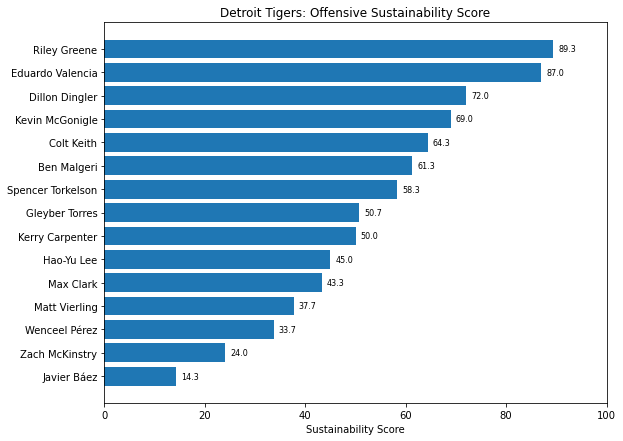

In [45]:
score_df = analysis_df.sort_values("Sustainability Score", ascending=True)

plt.figure(figsize=(9, 7))

plt.barh(
    score_df["Player Name"],
    score_df["Sustainability Score"]
)

plt.xlabel("Sustainability Score")
plt.title("Detroit Tigers: Offensive Sustainability Score")

for i, value in enumerate(score_df["Sustainability Score"]):
    plt.text(
        value + 1,
        i,
        f"{value:.1f}",
        va="center",
        fontsize=8
    )

plt.xlim(0, 100)

plt.savefig("sustainability_score_python.png", dpi=300, bbox_inches="tight")

plt.show()

## Key Findings

- Riley Greene showed one of the strongest overall underlying offensive profiles in the selected sample.
- Eduardo Valencia produced elite contact-quality indicators, although his actual results exceeded his expected metrics.
- Matt Vierling showed one of the largest positive xwOBA gaps, indicating stronger expected production than actual results.
- Kevin McGonigle stood out for plate discipline with the strongest BB/K profile in the sample.

## Limitations

- Rankings are relative only to the selected Tigers hitters.
- Sample sizes differ between players.
- Park effects, platoon splits, injuries, opponent quality, baserunning, and defense are not included.
- Expected statistics and the Sustainability Score should not be interpreted as guaranteed forecasts.